<a href="https://colab.research.google.com/github/ayushpaliwal1920/Deep_Learning/blob/main/20_he_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
from sklearn.datasets import make_classification
import pandas as pd

# generate data
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    flip_y=0.1,   # 10% labels randomly flipped / noise
    random_state=42,
    n_clusters_per_class=1,

)

# convert to DataFrame
df = pd.DataFrame(X, columns=['X', 'Y'])
df['class'] = y

print(df.head())

          X         Y  class
0  2.502258  2.548817      1
1 -0.676214  1.412767      0
2 -1.310385  0.556563      0
3  2.075149  2.209383      1
4  0.974777  1.045987      1


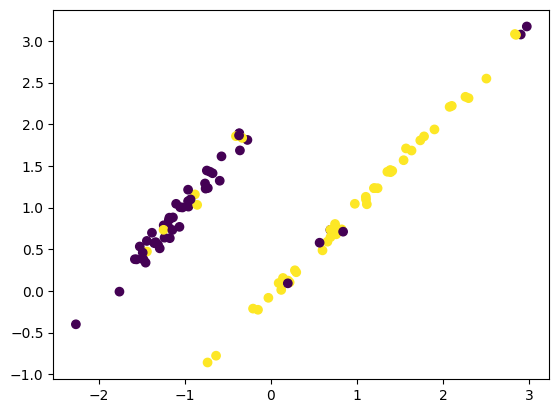

In [85]:
plt.scatter(df['X'],df['Y'],c=df['class'])


In [86]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [113]:
model1 = Sequential()

# he initialization : he_uniform / he_normal / or glorat_uniform

model1.add(Dense(10,activation='relu',input_dim =2,kernel_initializer = 'he_uniform'))
model1.add(Dense(10,activation='relu',kernel_initializer = 'he_uniform'))
model1.add(Dense(10,activation='relu',kernel_initializer = 'he_uniform'))
model1.add(Dense(10,activation='relu',kernel_initializer = 'he_uniform'))

model1.add(Dense(1,activation="sigmoid"))

model1.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
#  default values :

model1.get_weights()

[array([[ 0.42918622,  0.36645877,  0.50926363, -1.6446975 , -1.0505769 ,
          1.6146556 ,  0.6867279 ,  0.1623038 , -0.6762743 ,  0.25214827],
        [-1.3312328 , -1.3792633 ,  0.00325286,  1.1755255 ,  0.9945761 ,
          1.3728098 , -1.3458877 ,  1.129444  , -0.107535  , -0.57548106]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.31820098, -0.60848397,  0.17287803,  0.5216361 , -0.68130535,
         -0.76374537,  0.36927056, -0.6253268 ,  0.32361853,  0.74075055],
        [ 0.20721543, -0.16005713, -0.06387746, -0.6730403 ,  0.6143837 ,
          0.3021909 ,  0.70860374, -0.22848356,  0.50930274,  0.53856254],
        [-0.01355356, -0.44504833,  0.01461321, -0.44064525, -0.0964846 ,
         -0.34518063,  0.51197255, -0.07672328,  0.6391474 , -0.00773042],
        [-0.20343506, -0.4611292 , -0.04836041, -0.7195522 ,  0.62047493,
          0.32206404,  0.1612001 ,  0.4384936 ,  0.40135682, -0.62809086],
        [-0.75902

In [115]:
inital_weights = model1.get_weights()

In [116]:

inital_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
inital_weights[1] = np.zeros(model1.get_weights()[1].shape)
inital_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
inital_weights[3] = np.zeros(model1.get_weights()[3].shape)
inital_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
inital_weights[5] = np.zeros(model1.get_weights()[5].shape)
inital_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
inital_weights[7] = np.zeros(model1.get_weights()[7].shape)
inital_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
inital_weights[9] = np.zeros(model1.get_weights()[9].shape)


In [117]:
model1.set_weights(inital_weights)

In [118]:
model1.get_weights()

[array([[-1.3742932 , -0.7221049 , -0.6140585 , -0.91413957, -1.1216855 ,
         -0.10913366, -0.91390747, -0.51673883,  0.7049689 ,  0.658718  ],
        [ 0.67777246,  0.4869174 ,  0.17483734, -0.17968628,  0.7636824 ,
          1.4331415 , -1.6012319 , -0.09171142,  0.26548335,  0.14814374]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.37200972, -0.26433688, -0.20512766,  0.03379908,  0.2783496 ,
         -0.2266832 , -0.27789253, -0.24331897, -0.30084378, -0.24324648],
        [-0.76967806, -0.21767631,  0.37010705, -0.1258995 , -0.0527228 ,
          0.04365474,  0.5298529 ,  0.16534181, -0.5966224 ,  0.30703253],
        [ 0.14375228,  0.17160682, -0.07781671,  0.21997052, -0.1780336 ,
          0.27217665,  0.6285923 ,  0.28696284, -0.03267309,  0.49955565],
        [-0.05397198, -0.33994976, -0.21933046,  0.5215614 , -0.4157843 ,
          0.49292243,  0.5550172 , -0.07161918,  0.11738877,  0.24573617],
        [ 0.00617

In [119]:
model1.compile(loss="binary_crossentropy",optimizer = "adam",metrics = ['accuracy'])

In [120]:
history = model1.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.8500 - loss: 0.6642 - val_accuracy: 0.7000 - val_loss: 0.6728
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8625 - loss: 0.6583 - val_accuracy: 0.7000 - val_loss: 0.6687
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8750 - loss: 0.6513 - val_accuracy: 0.7000 - val_loss: 0.6648
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8750 - loss: 0.6455 - val_accuracy: 0.7000 - val_loss: 0.6607
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8750 - loss: 0.6388 - val_accuracy: 0.7500 - val_loss: 0.6569
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8875 - loss: 0.6331 - val_accuracy: 0.8000 - val_loss: 0.6530
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8750 - loss: 0.6260 - val_accuracy: 0.8500 - val_loss: 0.6495
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8750 - loss: 0.6199 - val_accuracy: 0.8500 - val_loss

In [121]:
model1.get_weights()

[array([[-1.3430303 , -0.90273595, -0.7665237 , -1.0809331 , -1.2916106 ,
         -0.0385479 , -0.8564373 , -0.3863391 ,  0.7750686 ,  0.71918267],
        [ 0.67309064,  0.56347066,  0.30894652, -0.05514733,  0.87559044,
          1.4746302 , -1.811425  , -0.17097697,  0.32118836,  0.2226072 ]],
       dtype=float32),
 array([-0.07180807,  0.20977153,  0.24643359,  0.10389905,  0.03181715,
         0.1423261 ,  0.16959621, -0.14519191,  0.19217768,  0.19214047],
       dtype=float32),
 array([[ 0.37200972, -0.29990003, -0.2803235 ,  0.17888348,  0.17427126,
         -0.2938811 , -0.14312355, -0.29678774, -0.30084378, -0.09587492],
        [-0.82491416, -0.23485118,  0.31312242,  0.01723431, -0.00767026,
         -0.0079111 ,  0.6617146 ,  0.12818818, -0.5966224 ,  0.48848295],
        [ 0.0824355 ,  0.17668864, -0.11474893,  0.36676428, -0.04115427,
          0.21814442,  0.76522595,  0.2764857 , -0.03267309,  0.694793  ],
        [-0.05397198, -0.2603968 , -0.17735438,  0.6820864 , 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 985us/step


<Axes: >

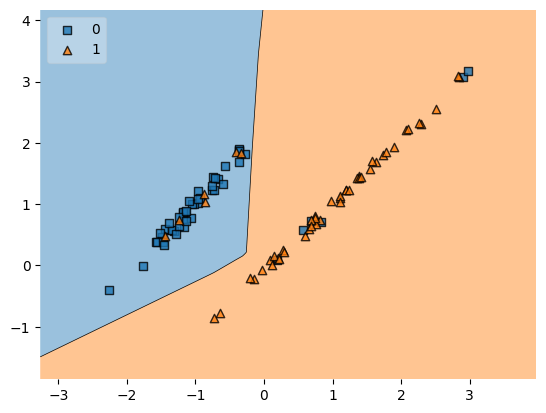

In [122]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X,
                      y=y.astype(int),
                      clf=model1,
                      legend=2)